# CycleGAN Patchwise Inference
Dieses Notebook zeigt, wie ein trainierter CycleGAN-Generator große Bilder 
per Kachelgitter verarbeitet. Patches werden einzeln konvertiert und anschließend 
durch einfaches Mittelwerten wieder zusammengesetzt. Passe die Parameter unten 
(Checkpoint, Bildpfad, Patchgröße/Stride) an deinen Anwendungsfall an.


In [11]:
import math
from pathlib import Path

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from monai.inferers import SlidingWindowInferer

import os

os.chdir("/srv/store/docker-users/thesis/khajuria/day2night")
print("Current working directory:", os.getcwd())


from src.utils.common import load_cfg, resolve_encoder_checkpoint
from src.models.cyclegan import CycleGANGenerator


Current working directory: /srv/store/docker-users/thesis/khajuria/day2night


In [12]:
# --- Benutzer-Parameter ---
CONFIG_PATH = "configs/cyclegan.yaml"
CHECKPOINT_PATH = None  # "experiments/cyclegan_day2night_20251110_172804/epoch_0200.pt" #None  # Optional: expliziter Pfad zu epoch_XXXX.pt
DIRECTION = "day2night"  # oder "night2day"
INPUT_IMAGE = "data/night2day/night_to_day/testA/1abbe94b-c840d3b2.jpg"
INPUT_RESIZE = None #(640, 360)  # None = Originalgröße behalten, oder (Breite, Höhe)
ADAPTIVE_STRIDE = True  # reduziert Überlappung bei kleinen Bildern
TILE_SIZE = 256
TILE_STRIDE = 192  # Basis-Stride, wird ggf. angepasst
USE_MONAI = True  # True = SlidingWindowInferer verwenden
MONAI_SW_BATCH = 4
MONAI_OVERLAP = None  # None = automatisch aus Stride/Tile berechnen
SAVE_RESULT = True
OUTPUT_DIR = "results/cyclegan_patches"
OUTPUT_SUFFIX = "patched"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [13]:
def find_checkpoint(cfg, explicit=None):
    if explicit:
        path = Path(explicit)
        if not path.is_file():
            raise FileNotFoundError(f"Checkpoint nicht gefunden: {path}")
        return path
    exp_root = Path(cfg["logging"]["out_dir"])
    pattern = sorted(exp_root.glob(f"{cfg['exp_name']}_*/epoch_*.pt"))
    if not pattern:
        raise RuntimeError(f"Keine Checkpoints unter {exp_root} gefunden.")
    return pattern[-1]


def build_generator(cfg, device):
    gen_cfg = cfg["model"]["generator"]
    encoder_ckpt = resolve_encoder_checkpoint(
        gen_cfg.get("encoder_checkpoint"),
        experiments_root=cfg["logging"].get("out_dir", "experiments"),
        default_run_prefix=gen_cfg.get("encoder_run_prefix", "seg"),
        filename=gen_cfg.get("encoder_filename", "encoder_GE.pth"),
    )
    model = CycleGANGenerator(
        in_channels=gen_cfg.get("in_channels", 3),
        out_channels=gen_cfg.get("out_channels", 3),
        base_channels=gen_cfg.get("base_channels", 64),
        n_res_blocks=gen_cfg.get("n_res_blocks", 9),
        use_skip=gen_cfg.get("use_skip", True),
        encoder_checkpoint=encoder_ckpt,
        freeze_encoder=gen_cfg.get("freeze_encoder", False),
        decoder_res_blocks=gen_cfg.get("decoder_res_blocks", 3),
    ).to(device)
    return model


def prepare_image_tensor(pil_image, tile_size, device):
    tensor = TF.to_tensor(pil_image).unsqueeze(0).to(device) * 2 - 1
    _, _, h, w = tensor.shape
    pad_h = max(0, tile_size - h)
    pad_w = max(0, tile_size - w)
    if pad_h > 0 or pad_w > 0:
        tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode="reflect")
    return tensor, h, w


def sliding_window_manual(generator, pil_image, tile_size=256, stride=128, device=torch.device("cpu")):
    base, orig_h, orig_w = prepare_image_tensor(pil_image, tile_size, device)
    base = base.squeeze(0)
    c, h, w = base.shape

    def make_coords(length):
        if length <= tile_size:
            return [0]
        coords = list(range(0, length - tile_size + 1, stride))
        if coords[-1] != length - tile_size:
            coords.append(length - tile_size)
        return coords

    ys = make_coords(h)
    xs = make_coords(w)
    accum = torch.zeros((c, h, w), device=device)
    weight = torch.zeros((1, h, w), device=device)
    patch_weight = torch.ones((1, tile_size, tile_size), device=device)

    generator.eval()
    with torch.inference_mode():
        for y in ys:
            for x in xs:
                patch = base[:, y:y+tile_size, x:x+tile_size].unsqueeze(0)
                out = generator(patch)
                accum[:, y:y+tile_size, x:x+tile_size] += out.squeeze(0) * patch_weight
                weight[:, y:y+tile_size, x:x+tile_size] += patch_weight

    weight = weight.clamp_min(1e-6)
    result = accum / weight
    return result[:, :orig_h, :orig_w]


def sliding_window_monai(generator, pil_image, tile_size=256, stride=128, device=torch.device("cpu"), sw_batch=4, overlap=None):
    tensor, orig_h, orig_w = prepare_image_tensor(pil_image, tile_size, device)
    if overlap is None:
        overlap = 1.0 - min(1.0, stride / float(tile_size))
        overlap = max(0.0, min(0.9, overlap))
    inferer = SlidingWindowInferer(
        roi_size=(tile_size, tile_size),
        sw_batch_size=sw_batch,
        overlap=overlap,
        padding_mode="reflect",
        mode="gaussian",
    )
    generator.eval()
    with torch.inference_mode():
        output = inferer(tensor, generator)
    return output.squeeze(0)[:, :orig_h, :orig_w]


def tensor_to_image(tensor):
    tensor = tensor.detach().clamp(-1, 1)
    tensor = (tensor + 1) / 2
    return TF.to_pil_image(tensor.cpu())



In [14]:
cfg = load_cfg(CONFIG_PATH)
checkpoint = find_checkpoint(cfg, CHECKPOINT_PATH)
print(f"Nutze Checkpoint: {checkpoint}")
key = "G" if DIRECTION == "day2night" else "F"
generator = build_generator(cfg, DEVICE)
generator.load_state_dict(torch.load(checkpoint, map_location="cpu", weights_only=True)[key])
generator.to(DEVICE)
generator.eval()
print(f"Generator für {DIRECTION} ist geladen und bereit.")


Nutze Checkpoint: experiments/cyclegan_day2night_20251124_002331/epoch_0200.pt


/tmp/ipykernel_1269184/2339208040.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(checkpoint, map_location="cpu")[key])


Generator für day2night ist geladen und bereit.


Gespeichert unter results/cyclegan_patches/day2night/1abbe94b-c840d3b2_patched.png


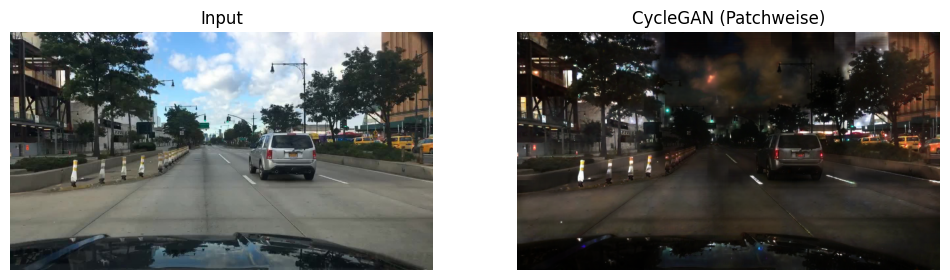

In [15]:
input_path = Path(INPUT_IMAGE)
if not input_path.is_file():
    raise FileNotFoundError(f"Eingangsbild nicht gefunden: {input_path}")
original = Image.open(input_path).convert("RGB")
processed_input = original
resize_note = None
if INPUT_RESIZE:
    if not isinstance(INPUT_RESIZE, (tuple, list)) or len(INPUT_RESIZE) != 2:
        raise ValueError("INPUT_RESIZE muss (Breite, Höhe) sein oder None")
    target_w, target_h = int(INPUT_RESIZE[0]), int(INPUT_RESIZE[1])
    if target_w <= 0 or target_h <= 0:
        raise ValueError("Breite/Höhe müssen positiv sein")
    processed_input = original.resize((target_w, target_h), Image.BICUBIC)
    resize_note = f"Input manuell auf {target_w}x{target_h} gesetzt."
if resize_note:
    print(resize_note + f" Original: {original.width}x{original.height}.")

fits_single_tile = processed_input.width <= TILE_SIZE and processed_input.height <= TILE_SIZE
effective_stride = TILE_STRIDE
adaptive_note = None
if ADAPTIVE_STRIDE and not fits_single_tile:
    max_dim = max(processed_input.width, processed_input.height)
    if max_dim <= TILE_SIZE * 1.5:
        effective_stride = TILE_SIZE
        adaptive_note = f"Adaptive Stride: nutze {effective_stride}px (kein overlap) für kompaktere Bilder."
    else:
        effective_stride = TILE_STRIDE
else:
    effective_stride = TILE_STRIDE
if adaptive_note:
    print(adaptive_note)

if fits_single_tile:
    print("Bild passt in eine einzelne Kachel -> direkter Durchlauf ohne Sliding Window.")
    with torch.inference_mode():
        tensor = TF.to_tensor(processed_input).unsqueeze(0).to(DEVICE) * 2 - 1
        output_tensor = generator(tensor).squeeze(0)
else:
    if USE_MONAI:
        output_tensor = sliding_window_monai(
            generator,
            processed_input,
            tile_size=TILE_SIZE,
            stride=effective_stride,
            device=DEVICE,
            sw_batch=MONAI_SW_BATCH,
            overlap=MONAI_OVERLAP,
        )
    else:
        output_tensor = sliding_window_manual(
            generator,
            processed_input,
            tile_size=TILE_SIZE,
            stride=effective_stride,
            device=DEVICE,
        )

result_img = tensor_to_image(output_tensor)

if SAVE_RESULT:
    out_dir = Path(OUTPUT_DIR) / DIRECTION
    out_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"_{OUTPUT_SUFFIX}" if OUTPUT_SUFFIX else ""
    out_path = out_dir / f"{input_path.stem}{suffix}.png"
    result_img.save(out_path)
    print(f"Gespeichert unter {out_path}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(processed_input)
if resize_note:
    title = "Input (manuell resized)"
else:
    title = "Input"
plt.title(title)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_img)
plt.title("CycleGAN (Patchweise)" if not fits_single_tile else "CycleGAN (Single Pass)")
plt.axis("off")
plt.show()

